# Lesson 04 - PyTorch basics: autograd, nn.Module, a clean training loop; lesson 02 again.


Questions this lesson answers
-----------------------------
* What does autograd actually do, and how does it relate to our hand-written backprop?
* How do I add my own differentiable operation (torch.autograd.Function) and check it?
* What does a clean, idiomatic PyTorch training loop look like?
* Do PyTorch and our NumPy MLP give the *same* numbers? (Yes: to ~1e-15 in float64.)

Script version:  python lessons/04_pytorch_basics/lesson.py

## Lesson 04 - PyTorch basics

📄 [`lessons/04_pytorch_basics/lesson.py`](../lessons/04_pytorch_basics/lesson.py) · 📓 [`notebooks/04_pytorch_basics.ipynb`](04_pytorch_basics.ipynb) · code: [`nnaz/torch_basics.py`](../nnaz/torch_basics.py)

### Autograd = backprop that writes itself

Every operation on a tensor with `requires_grad=True` records a node in a **computational
graph**: `f.grad_fn` points to `AddBackward0`, which points to `MulBackward0` and `SinBackward0`,
and so on. `f.backward()` walks the graph from the output back to the leaves. At each node it
multiplies the incoming gradient by that operation's local Jacobian. This is exactly what our
`Layer.backward` methods did by hand in lesson 02, done automatically for any composition of
operations. This is *reverse-mode* automatic differentiation: one backward sweep gives the
gradient with respect to **all** inputs, which is ideal for one scalar loss and millions of
parameters. It is not finite differences, so the derivatives are exact up to round-off.

Because the backward pass is itself built from differentiable operations, we can differentiate
again. `torch.autograd.grad(..., create_graph=True)` gives second and third derivatives. PINNs
(lesson 09) and Hamiltonian networks (lesson 15) rely on this.

A **custom operation** subclasses `torch.autograd.Function` and implements both `forward` and
`backward`. Here `softplus(x) = log(1 + e^x)` with derivative `sigmoid(x)`. It is verified with
`torch.autograd.gradcheck`, PyTorch's built-in version of our lesson-02 gradient check.

<p align="center"><img src="../docs/lesson04/autograd_derivatives.png" width="45%"></p>

### The canonical training loop

```python
for epoch in range(epochs):
    model.train()                       # dropout / batch-norm in training mode
    for xb, yb in loader:               # DataLoader shuffles and batches
        opt.zero_grad()                 # gradients ACCUMULATE by default
        loss = loss_fn(model(xb), yb)   # forward: builds the graph
        loss.backward()                 # backward: fills p.grad for every parameter
        opt.step()                      # update using p.grad
    model.eval()
    with torch.no_grad(): ...           # evaluation: no graph, less memory
```

### Same numbers as our NumPy code

We copy the weights of the lesson-02 NumPy MLP into an `nn.Module`. `nn.Linear` stores $W^\top$,
so the weights are transposed. We then run full-batch gradient descent in **both** libraries in
float64. At lr = 0.1 the two loss curves agree to round-off ($10^{-16}$) for 300 steps. At
lr = 0.5 they agree until about step 160, then diverge to $O(1)$ differences. Neither library
is wrong: at that learning rate gradient descent becomes unstable (see the loss spike). The
dynamics turn chaotic and amplify the $10^{-16}$ difference in summation order, just as a
turbulent flow amplifies round-off. This is a useful reminder that bit-for-bit reproducibility
across libraries is only possible in a stable regime.

<p align="center"><img src="../docs/lesson04/numpy_vs_torch.png" width="85%"></p>

*(see the results table in the README)*



In [1]:
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `nnaz` importable
from nnaz.notebooks import show_new_figures

from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from nnaz.common import (banner, decision_grid, save_results, savefig, seed_everything,
                         set_torch_threads, setup_matplotlib)
from nnaz.data import spirals
from nnaz.mlp_numpy import MLP
from nnaz.torch_basics import MySoftplus, TorchMLP, numpy_vs_torch_gd, to_tensors, train_loop
LESSON = 4
plt = setup_matplotlib()

## 1. Autograd: a recorded graph, walked backwards

In [2]:
def autograd_part():
    banner("1. Autograd: a recorded graph, walked backwards")
    # f(x, y) = x^2 y + sin(x y);  df/dx = 2xy + y cos(xy),  df/dy = x^2 + x cos(xy)
    x = torch.tensor(1.5, dtype=torch.float64, requires_grad=True)
    y = torch.tensor(-0.7, dtype=torch.float64, requires_grad=True)
    f = x ** 2 * y + torch.sin(x * y)
    print(f"  f = {f.item():.6f}; the graph ends in {f.grad_fn} <- {f.grad_fn.next_functions}")
    f.backward()
    dx = 2 * 1.5 * -0.7 + -0.7 * np.cos(1.5 * -0.7)
    dy = 1.5 ** 2 + 1.5 * np.cos(1.5 * -0.7)
    print(f"  autograd  df/dx = {x.grad.item():.12f}   by hand {dx:.12f}")
    print(f"  autograd  df/dy = {y.grad.item():.12f}   by hand {dy:.12f}")
    err_hand = max(abs(x.grad.item() - dx), abs(y.grad.item() - dy))

    # Custom op, verified by torch's own finite-difference checker (needs float64)
    z = torch.randn(20, dtype=torch.float64, requires_grad=True)
    ok = torch.autograd.gradcheck(MySoftplus.apply, (z,), eps=1e-6, atol=1e-8)
    print(f"  torch.autograd.gradcheck(MySoftplus): {ok}")

    # Higher derivatives: differentiate the gradient itself (create_graph=True)
    t = torch.linspace(-4, 4, 400, dtype=torch.float64, requires_grad=True)
    ys = [torch.tanh(t)]
    for _ in range(3):
        (g,) = torch.autograd.grad(ys[-1].sum(), t, create_graph=True)
        ys.append(g)
    # exact: tanh' = 1 - tanh^2, tanh'' = -2 tanh (1 - tanh^2)
    th = np.tanh(t.detach().numpy())
    err_d1 = np.abs(ys[1].detach().numpy() - (1 - th ** 2)).max()
    err_d2 = np.abs(ys[2].detach().numpy() - (-2 * th * (1 - th ** 2))).max()
    print(f"  d/dt tanh and d2/dt2 tanh by nested autograd: max error {err_d1:.1e}, {err_d2:.1e}")
    fig, ax = plt.subplots(figsize=(5.5, 3.6))
    for k, yk in enumerate(ys):
        ax.plot(t.detach(), yk.detach(), label=["tanh", "1st derivative", "2nd", "3rd"][k])
    ax.set_title("derivatives of tanh by repeated autograd"); ax.legend()
    savefig(fig, LESSON, "autograd_derivatives.png")
    return dict(autograd_vs_hand_err=err_hand, custom_op_gradcheck=bool(ok),
                nested_grad_err_d1=float(err_d1), nested_grad_err_d2=float(err_d2))

## 2. The NumPy MLP of lesson 02 and PyTorch, from identical weights

In [3]:
def equivalence_part(rng):
    banner("2. The NumPy MLP of lesson 02 and PyTorch, from identical weights")
    X, y = spirals(300, rng)
    out, curves = {}, {}
    for lr in (0.1, 0.5):
        np_model = MLP([2, 32, 32, 3], np.random.default_rng(0), act="tanh", init="xavier")
        ln, lt, gdiff = numpy_vs_torch_gd(np_model, X, y, steps=300, lr=lr)
        diff = np.abs(ln - lt)
        curves[lr] = (ln, lt, diff)
        print(f"  lr {lr}: gradients at step 0 max |numpy - torch| = {gdiff:.1e};  over 300 full-batch GD"
              f" steps max |loss difference| = {diff.max():.1e}  (loss {ln[0]:.3f} -> {ln[-1]:.3f})")
        out[f"lr{lr}"] = dict(grad_diff_step0=gdiff, max_loss_diff=float(diff.max()),
                              loss_first=ln[0], loss_last=ln[-1])
    # At lr 0.5 the loss spikes (GD becomes unstable): the dynamics turn chaotic and
    # amplify the 1e-16 round-off differences between the two libraries.
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
    for lr, (ln, lt, diff) in curves.items():
        l, = axs[0].plot(ln, lw=3, alpha=0.4, label=f"NumPy, lr {lr}")
        axs[0].plot(lt, "--", color=l.get_color(), lw=1, label=f"PyTorch, lr {lr}")
        axs[1].semilogy(diff + 1e-17, color=l.get_color(), label=f"lr {lr}")
    axs[0].set_xlabel("GD step"); axs[0].set_ylabel("loss"); axs[0].legend(fontsize=8)
    axs[0].set_title("same weights, same data, two libraries")
    axs[1].set_xlabel("GD step"); axs[1].legend()
    axs[1].set_title("|loss NumPy - loss PyTorch|")
    savefig(fig, LESSON, "numpy_vs_torch.png")
    return {"equivalence": out}

## 3. A clean training loop: Dataset, DataLoader, nn.Module, optimiser

In [4]:
def training_part(rng, quick):
    banner("3. A clean training loop: Dataset, DataLoader, nn.Module, optimiser")
    X, y = spirals(600, rng)
    Xte, yte = spirals(1500, rng)
    ds = TensorDataset(*to_tensors(X, y))
    loader = DataLoader(ds, batch_size=64, shuffle=True)  # shuffles every epoch
    model = TorchMLP([2, 64, 64, 3])
    print(model)
    n_par = sum(p.numel() for p in model.parameters())
    hist = train_loop(model, loader, to_tensors(Xte, yte), epochs=30 if quick else 300, lr=1e-2, log=50)
    gx, gy, G = decision_grid(X)
    with torch.no_grad():
        pred = model(torch.as_tensor(G, dtype=torch.float32)).argmax(1).numpy()
    fig, axs = plt.subplots(1, 2, figsize=(9, 3.8))
    axs[0].contourf(gx, gy, pred.reshape(gx.shape), levels=[-.5, .5, 1.5, 2.5], cmap="Pastel1")
    axs[0].scatter(*X.T, c=y, cmap="Set1", s=5, vmin=0, vmax=8)
    axs[0].set_title(f"PyTorch MLP, test acc {hist['val_acc'][-1]:.3f}"); axs[0].set_aspect("equal")
    axs[1].semilogy(hist["loss"], label="train"); axs[1].semilogy(hist["val_loss"], label="test")
    axs[1].set_xlabel("epoch"); axs[1].legend(); axs[1].set_title("cross-entropy")
    savefig(fig, LESSON, "torch_spiral.png")
    return dict(n_params=n_par, torch_test_acc=hist["val_acc"][-1], torch_loss_first=hist["loss"][0],
                torch_loss_last=hist["loss"][-1])

## Run the lesson

Set `quick = True` for a fast pass (fewer epochs; numbers will differ from the README).

In [5]:
quick = False

In [6]:
rng = seed_everything(4)

In [7]:
set_torch_threads()


1. Autograd: a recorded graph, walked backwards
  f = -2.442423; the graph ends in <AddBackward0 object at 0x7fd9c33b9570> <- ((<MulBackward0 object at 0x7fd9c2b36800>, 0), (<SinBackward0 object at 0x7fd9c2b35750>, 0))
  autograd  df/dx = -2.448299733524   by hand -2.448299733524
  autograd  df/dy = 2.996356571838   by hand 2.996356571838


  torch.autograd.gradcheck(MySoftplus): True
  d/dt tanh and d2/dt2 tanh by nested autograd: max error 2.7e-16, 5.4e-16
  saved docs/lesson04/autograd_derivatives.png


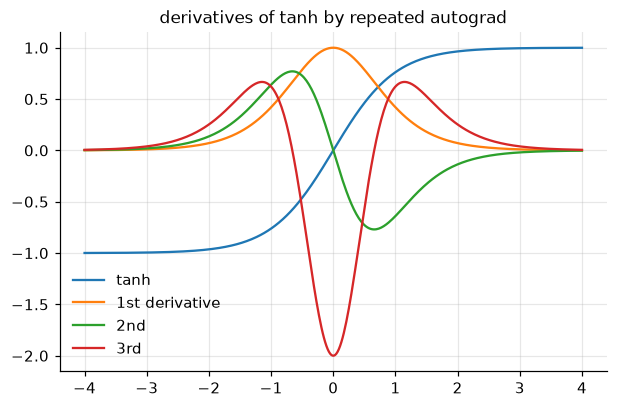

In [8]:
t0 = time.time()
res = autograd_part()
show_new_figures(t0, LESSON)


2. The NumPy MLP of lesson 02 and PyTorch, from identical weights


  lr 0.1: gradients at step 0 max |numpy - torch| = 1.6e-16;  over 300 full-batch GD steps max |loss difference| = 4.4e-16  (loss 1.067 -> 1.021)


  lr 0.5: gradients at step 0 max |numpy - torch| = 1.6e-16;  over 300 full-batch GD steps max |loss difference| = 1.3e+00  (loss 1.067 -> 0.592)


  saved docs/lesson04/numpy_vs_torch.png


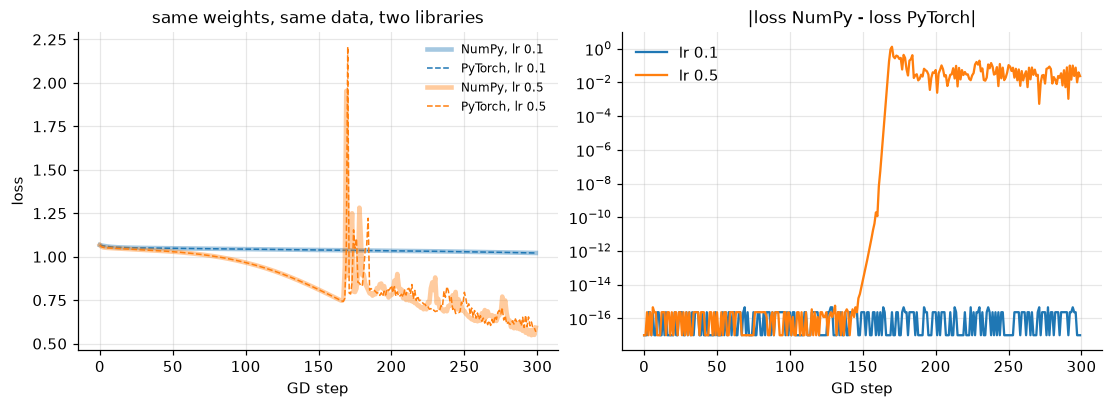

In [9]:
t0 = time.time()
res.update(equivalence_part(rng))
show_new_figures(t0, LESSON)


3. A clean training loop: Dataset, DataLoader, nn.Module, optimiser
TorchMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
  epoch   0  train loss 1.0723  val acc 0.385


  epoch  50  train loss 0.0054  val acc 0.997


  epoch 100  train loss 0.0011  val acc 0.997


  epoch 150  train loss 0.0004  val acc 0.997


  epoch 200  train loss 0.0002  val acc 0.997


  epoch 250  train loss 0.0001  val acc 0.997


  epoch 299  train loss 0.0001  val acc 0.997


  saved docs/lesson04/torch_spiral.png


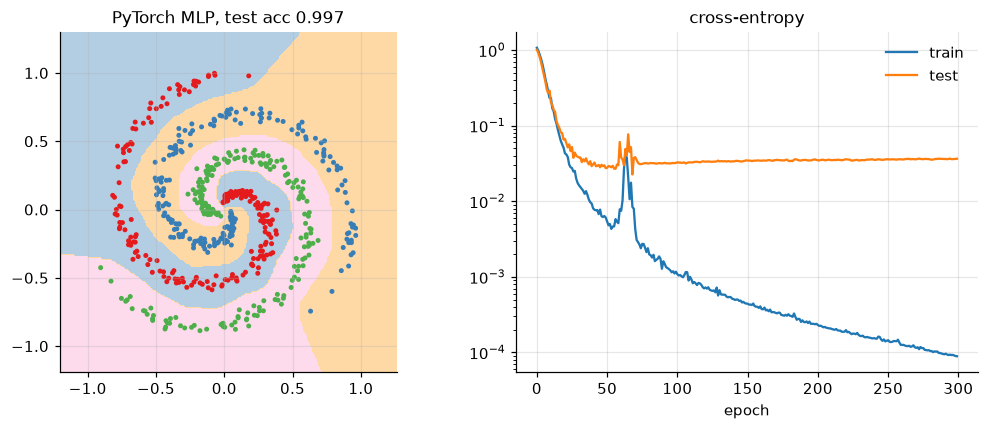

In [10]:
t0 = time.time()
res.update(training_part(rng, quick))
show_new_figures(t0, LESSON)

In [11]:
_ = save_results(LESSON, res)

In [12]:
res  # all numbers of this run

{'autograd_vs_hand_err': np.float64(0.0),
 'custom_op_gradcheck': True,
 'nested_grad_err_d1': 2.740863092043355e-16,
 'nested_grad_err_d2': 5.447031714567174e-16,
 'equivalence': {'lr0.1': {'grad_diff_step0': np.float64(1.6046192152785466e-16),
   'max_loss_diff': 4.440892098500626e-16,
   'loss_first': np.float64(1.0671616881446957),
   'loss_last': np.float64(1.021471884252949)},
  'lr0.5': {'grad_diff_step0': np.float64(1.6046192152785466e-16),
   'max_loss_diff': 1.316314553324594,
   'loss_first': np.float64(1.0671616881446957),
   'loss_last': np.float64(0.5917738488314338)}},
 'n_params': 4547,
 'torch_test_acc': 0.996666669845581,
 'torch_loss_first': 1.0722699276606242,
 'torch_loss_last': 8.91288329148665e-05}